## LaGuardia Flight Delays (May/June 2009): Case Study
This notebook explores the flight delay data (explained below). First, we start by viewing the data graphically, and start to answer questions about the data.

In [154]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Settings
plt.style.use("ggplot")

#### Read Data
The flight delay data is from the GitHub repo (https://github.com/lchihara/MathStatsResamplingR) from the book *Mathematical Statisticsc with Resampling and R* (Chihara, Hesterberg).

This dataset contains flight departure information from LaGuardia airport during May and June 2009 for United Airlines and American Airlines.

In [155]:
# Read data
flight_delays = pd.read_csv("../Data/FlightDelays.csv")

# Metadata
print(flight_delays["Carrier"].unique())
print(flight_delays.head())
print(flight_delays.describe())

<StringArray>
['UA', 'AA']
Length: 2, dtype: str
   ID Carrier  FlightNo Destination DepartTime  Day Month  FlightLength  \
0   1      UA       403         DEN      4-8am  Fri   May           281   
1   2      UA       405         DEN     8-Noon  Fri   May           277   
2   3      UA       409         DEN      4-8pm  Fri   May           279   
3   4      UA       511         ORD     8-Noon  Fri   May           158   
4   5      UA       667         ORD      4-8am  Fri   May           143   

   Delay Delayed30  
0     -1        No  
1    102       Yes  
2      4        No  
3     -2        No  
4     -3        No  
                ID     FlightNo  FlightLength        Delay
count  4029.000000  4029.000000   4029.000000  4029.000000
mean   2015.000000   827.103500    185.301067    11.737900
std    1163.216446   551.309387     41.787826    41.630495
min       1.000000    71.000000     68.000000   -19.000000
25%    1008.000000   371.000000    155.000000    -6.000000
50%    2015.000000  

#### Dataset Exploration
First, we explore the dataset graphically. We view the departure time bar chart, and the flight length and delay histograms.

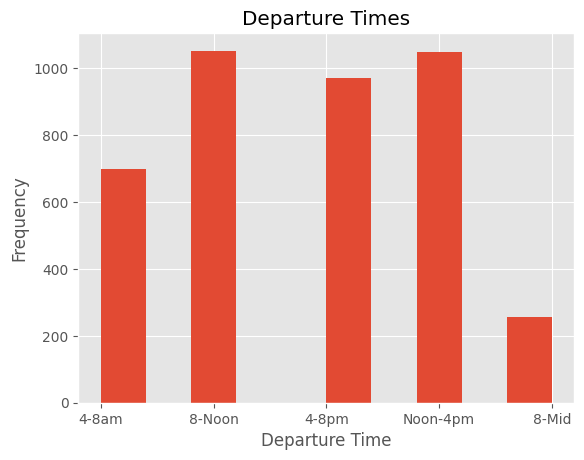

In [156]:
plt.hist(flight_delays["DepartTime"])
plt.title("Departure Times")
plt.ylabel("Frequency")
plt.xlabel("Departure Time")
plt.show()

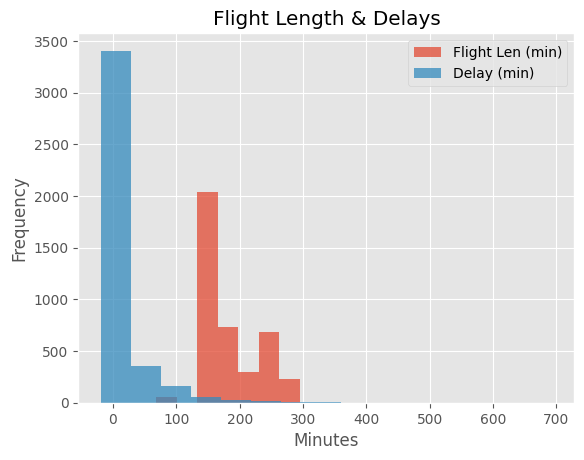

In [157]:
plt.hist(flight_delays["FlightLength"], label="Flight Len (min)", alpha=0.75, bins=7)
plt.hist(flight_delays["Delay"], label="Delay (min)", alpha=0.75, bins=15)
plt.legend()
plt.title("Flight Length & Delays")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

#### Day of Week and 30-Minute Delay Relationship
This section explores the relationship between the day of the week and percentage of flights delayed by at least 30 minutes.

In [158]:
contingency_table = pd.crosstab(
    flight_delays["Day"],
    flight_delays["Delayed30"]
)
contingency_table["pct. delayed"] = contingency_table["Yes"] / contingency_table.sum(axis=1)


print(contingency_table)

Delayed30   No  Yes  pct. delayed
Day                              
Fri        493  144      0.226060
Mon        569   61      0.096825
Sat        406   47      0.103753
Sun        507   44      0.079855
Thu        434  132      0.233216
Tue        535   93      0.148089
Wed        488   76      0.134752


The two days with the hightest percetnage of flights delayed by at least 30 minutes are Thursday(~23.3%) and Friday(~22.6%).

#### Relationhip Between Delayed Filghts and Flight Length
The next section of the analysis looks at the relationship between flight delays and flight lengths.

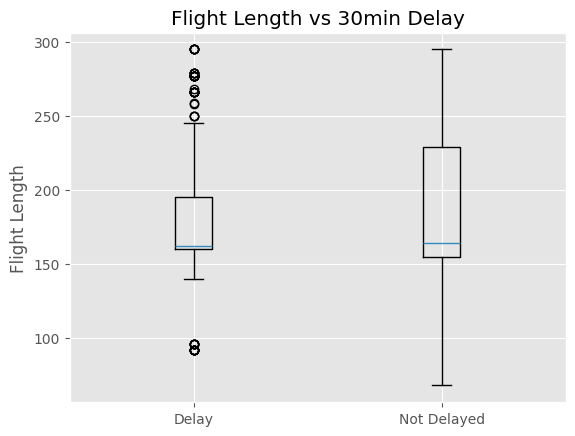

In [159]:
# Get flight length of delayed flights
flight_delayed = flight_delays.loc[
    flight_delays["Delayed30"] == "Yes", "FlightLength"
]
# Get flight length of non-delayed flights
flight_nondelayed = flight_delays.loc[
    flight_delays["Delayed30"] == "No", "FlightLength"
]

# Create box plots
fig, ax = plt.subplots()
ax.boxplot(
    [flight_delayed, flight_nondelayed]
)

ax.set_title("Flight Length vs 30min Delay")
ax.set_xticklabels(["Delay", "Not Delayed"])
ax.set_ylabel("Flight Length")
plt.show()

From the box-plot above, it appears that flights that are delayed at least 30 minutes appear to be concentrated between flight lengths of 150 and 200 minutes (with additional outliers). The non-delayed flights have a greater flight length spread. The medians of flight lengths are similar for delayed and non-delayed flights. This suggests there is no significant relationship between the length of the flight and whether or not is was delayed by at least 30 minutes.

### Hypothesis Testing: Mean Airline Delays
United airlines and American airlines have different mean delay times. The section below conducts two permutation tests.
- Difference in mean flight delays between airlines
- Difference in mean flight delays between the months of May and June

#### Part 1: Difference in mean flight delays between airlines.
Let $\mu_{AA}$ be the mean American Airlines delay time. Let $\mu_{UA}$ be the mean United Airlines delay time.

$H_0:\mu_{AA}=\mu_{UA}$<br>
$H_A:\mu_{AA}\ne\mu_{UA}$

The test statistic is:<br>
$T=\bar{AA}-\bar{UA}$

In [160]:
aa_delays = flight_delays.loc[
    flight_delays["Carrier"] == "AA", "Delay"
]

ua_delays = flight_delays.loc[
    flight_delays["Carrier"] == "UA", "Delay"
]

mu_aa = aa_delays.mean()
mu_ua = ua_delays.mean()

# Compute the observed test statistic
t_obs = mu_aa - mu_ua

print(f"mu AA: {mu_aa} | mu UA: {mu_ua}")
print(f"Observed Test Statistic: {t_obs}")

mu AA: 10.097384721266346 | mu UA: 15.983081032947462
Observed Test Statistic: -5.885696311681116


In [161]:
delay_pool = list(aa_delays) + list(ua_delays)
n = len(aa_delays)

B = 5_000
t_perm = []
for b in range(B):
    np.random.shuffle(delay_pool)
    s1 = delay_pool[:n]
    s2 = delay_pool[n:]

    t_perm.append(np.mean(s1) - np.mean(s2))

# Compute the p-value
count = np.sum(np.abs(t_perm) >= np.abs(t_obs))
p_val = (count + 1) / (B + 1)

print(f"P-Value: {p_val}")

P-Value: 0.0001999600079984003


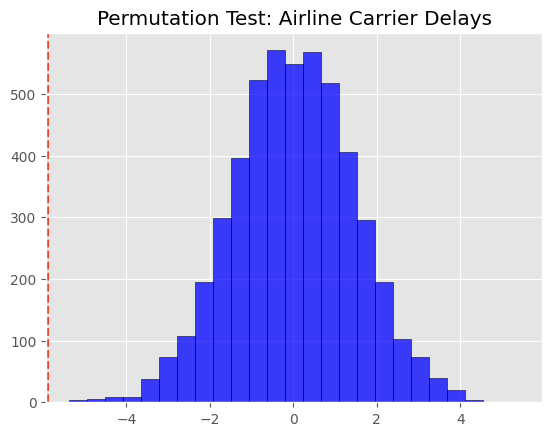

In [162]:
plt.hist(t_perm, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(t_obs, linestyle="dashed")
plt.title("Permutation Test: Airline Carrier Delays")
plt.show()

As we can see from the p-value above, we can reject the null hypothesis and conclude that there is a statistically significant difference in the mean delay times between the two airline carriers.

#### Part 2: Difference in flight delays between May and June 2009.
Let $\mu_M$ be the mean flight delay time in May and $\mu_J$ be the mean flight delay time in June.

$H_0:\mu_M=\mu_J$<br>
$H_A:\mu_M\ne\mu_J$

The test statistic is:<br>
$T=\bar{May}-\bar{June}$

In [163]:
may_delays = flight_delays.loc[
    flight_delays["Month"] == "May", "Delay"
]

june_delays = flight_delays.loc[
    flight_delays["Month"] == "June", "Delay"
]

mu_may = may_delays.mean()
mu_june = june_delays.mean()

# Compute the observed test statistic
t_obs = mu_may - mu_june

print(f"mu May: {mu_may} | mu June: {mu_june}")
print(f"Observed Test Statistic: {t_obs}")

mu May: 8.884442221110556 | mu June: 14.547783251231527
Observed Test Statistic: -5.6633410301209715


In [164]:
delay_pool = list(may_delays) + list(june_delays)
n = len(may_delays)

B = 5_000
t_perm = []
for b in range(B):
    np.random.shuffle(delay_pool)
    s1 = delay_pool[:n]
    s2 = delay_pool[n:]

    t_perm.append(np.mean(s1) - np.mean(s2))

# Compute two-sided p-value
count = np.sum(np.abs(t_perm) >= np.abs(t_obs))
p_val = (count + 1) / (B + 1)

print(f"P-Value: {p_val}")

P-Value: 0.0001999600079984003


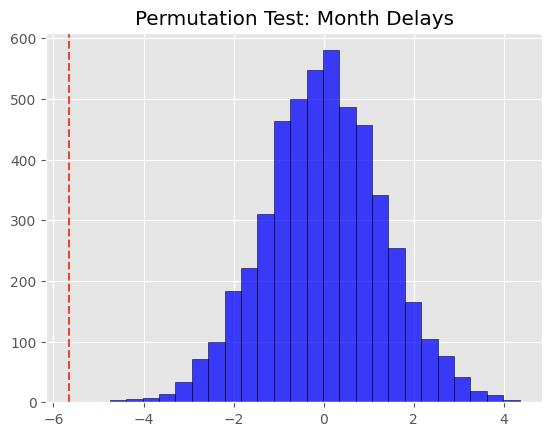

In [165]:
plt.hist(t_perm, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(t_obs, linestyle="dashed")
plt.title("Permutation Test: Month Delays")
plt.show()

As we can see from the p-value above, we can reject the null hypothesis and conclude that there is in fact a difference in the mean delay times between May and June 2009.